# Thermostat Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.4` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton for further how this is implemented please have a look at the bouncing ball source code in `hybrid_automatons` pkg.

![Thermostat Automaton Diagram](./figures/thermostat.png)

In [21]:
from hybrid_automatons import thermostat
from hybrid_automaton import Automaton
from hybrid_automaton_runner import AutomatonRunner
import numpy as np

In [22]:
ha: Automaton = thermostat(
    too_cold_threshold=18.0, 
    too_hot_threshold=22.0,
    ambient_temp=20.0,
    drift_rate=0.5
)
print (ha)

Hybrid Automaton Definition:
	name: Thermostat
	id: 3
	initial_mode: IDLE
	modes: [HEATING, COOLING, IDLE]
	transitions:
		HEATING --[heating_to_idle]--> IDLE
		COOLING --[cooling_to_idle]--> IDLE
		IDLE --[idle_to_heating]--> HEATING
		IDLE --[idle_to_cooling]--> COOLING
	guards:
		heating_to_idle: [temp_comfortable]
		cooling_to_idle: [temp_comfortable]
		idle_to_heating: [too_cold]
		idle_to_cooling: [too_hot]
	resets:
		heating_to_idle: <none>
		cooling_to_idle: <none>
		idle_to_heating: <none>
		idle_to_cooling: <none>
	invariants:
		HEATING: [<none>]
		COOLING: [<none>]
		IDLE: [<none>]
	continous_dynamics:
		HEATING -> heating_dynamics
		COOLING -> cooling_dynamics
		IDLE -> idle_dynamics



In [23]:
print (f"Hybrid Automaton `.mmd` diagram: \n\n{repr(ha)}")

Hybrid Automaton `.mmd` diagram: 

stateDiagram-v2
    direction LR
    [*] --> IDLE
    HEATING --> IDLE: heating_to_idle
    COOLING --> IDLE: cooling_to_idle
    IDLE --> HEATING: idle_to_heating
    IDLE --> COOLING: idle_to_cooling


In [24]:
ha_runner: AutomatonRunner = AutomatonRunner(hybrid_automaton=ha, sampling_rate=0.001)
await ha_runner.run(x0 = np.array([15.0]), real_time_mode=False, duration=10.0, integrate=True, dt=0.01, collect_continuous=True, collect_automaton=True, collect_control=False, collect_auxiliary=False)

🔥 HEATING - Turning heater ON
😌 IDLE - Systems off, maintaining temperature
AutomatonRunner: Duration 10.0 seconds elapsed, stopping simulation.


{'continuous_states': [[0.01, array([15.025])],
  [0.02, array([15.045])],
  [0.03, array([15.065])],
  [0.04, array([15.085])],
  [0.05, array([15.105])],
  [0.060000000000000005, array([15.125])],
  [0.07, array([15.145])],
  [0.08, array([15.165])],
  [0.09, array([15.185])],
  [0.09999999999999999, array([15.205])],
  [0.10999999999999999, array([15.225])],
  [0.11999999999999998, array([15.245])],
  [0.12999999999999998, array([15.265])],
  [0.13999999999999999, array([15.285])],
  [0.15, array([15.305])],
  [0.16, array([15.325])],
  [0.17, array([15.345])],
  [0.18000000000000002, array([15.365])],
  [0.19000000000000003, array([15.385])],
  [0.20000000000000004, array([15.405])],
  [0.21000000000000005, array([15.425])],
  [0.22000000000000006, array([15.445])],
  [0.23000000000000007, array([15.465])],
  [0.24000000000000007, array([15.485])],
  [0.25000000000000006, array([15.505])],
  [0.26000000000000006, array([15.525])],
  [0.2700000000000001, array([15.545])],
  [0.28000

In [25]:
print (repr(ha))

stateDiagram-v2
    direction LR
    [*] --> IDLE
    HEATING --> IDLE: heating_to_idle
    COOLING --> IDLE: cooling_to_idle
    IDLE --> HEATING: idle_to_heating
    IDLE --> COOLING: idle_to_cooling


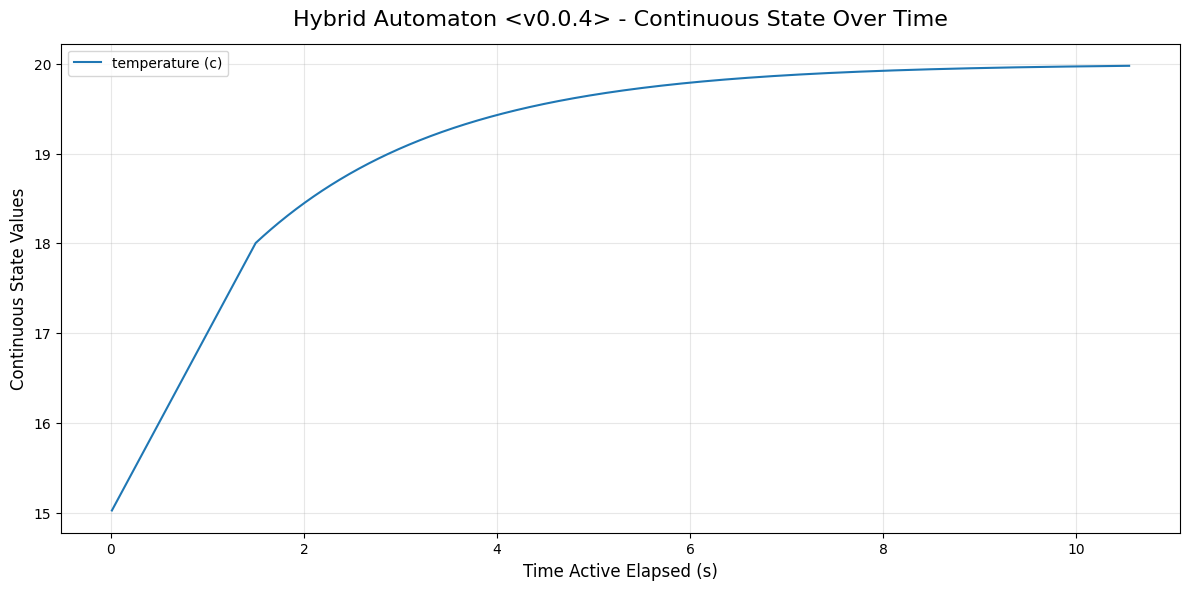

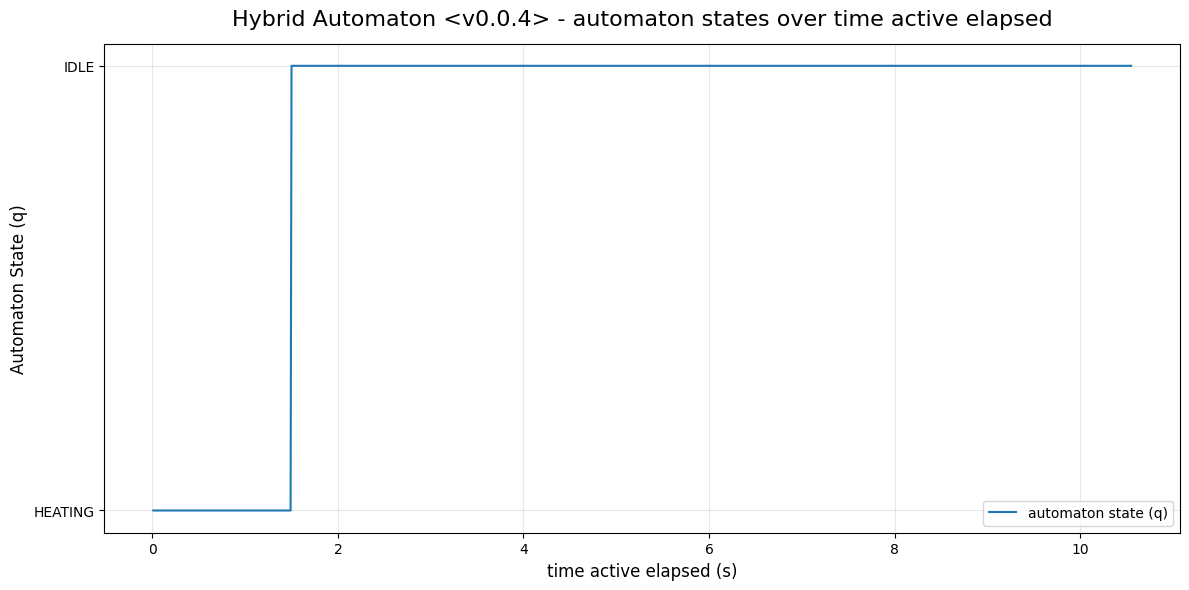

In [26]:
from hybrid_automaton_evaluation.visualization import continuous_states_over_time_fig, transitions_times_over_time_fig, automaton_states_over_time
import matplotlib.pyplot as plt

results = ha_runner.get_results()
fig1 = continuous_states_over_time_fig(results['continuous_states'], ['temperature (c)'])
# fig2 = transitions_times_over_time_fig(results['transition_times'])
fig3 = automaton_states_over_time(results['automaton_states'])

plt.show()

IndexError: tuple index out of range

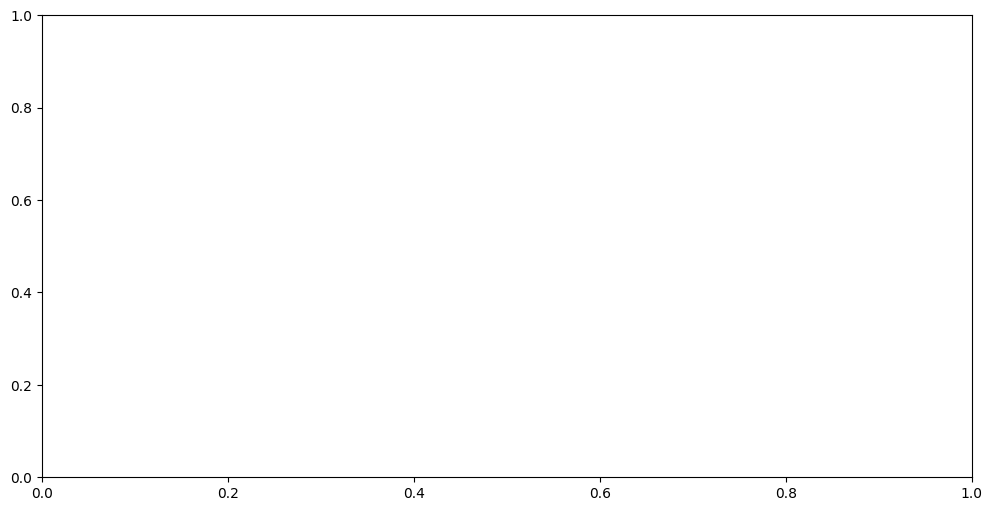

In [30]:
ha_runner: AutomatonRunner = AutomatonRunner(hybrid_automaton=ha, sampling_rate=0.001)
await ha_runner.run(x0 = np.array([30.0]), collect_continuous=True, collect_automaton=True, real_time_mode=False, duration=30.0, integrate=True, dt=0.01, collect_control=False, collect_auxiliary=False)

results = []
results = ha_runner.get_results()
fig1 = continuous_states_over_time_fig(results['continuous_states'], ['temperature (c)'])
# fig2 = transitions_times_over_time_fig(results['transition_times'])
fig3 = automaton_states_over_time(results['automaton_states'])

plt.show()